# ex008_PHT3D_08

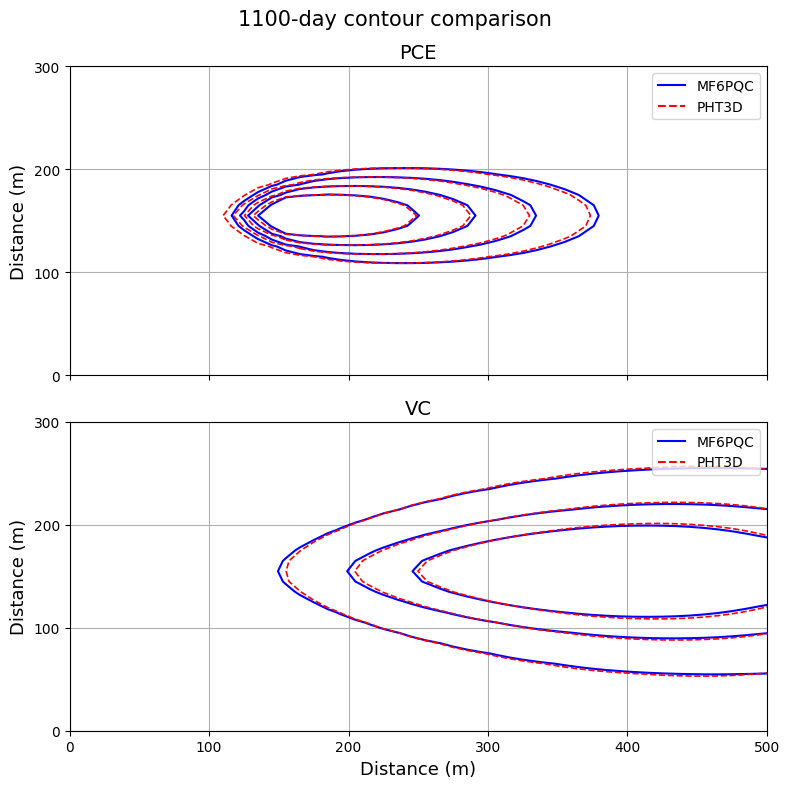

,RMSE (mg/L),Spatial correlation
Variable,,
PCE,0.176592,0.998907
VC,0.0286211,0.999225


In [1]:
import pandas as pd
from IPython.display import display

comparison_rows = []
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
output = CASE_DIR / "output"
results = np.load(output / "results.npy")
headings = (output / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
times = np.load(output / "results_times.npy")
CASE_DIR = Path.cwd()
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = output
NROW, NCOL = (31, 51)
DT_DAYS = 20.0
TARGET_TIME = 1100.0
PCE_MG_PER_MOL = 1000.0 * 165.8
VC_MG_PER_MOL = 1000.0 * 62.45
PCE_LEVELS = np.array([1.0, 2.0, 4.0, 8.0])
VC_LEVELS = np.array([0.1, 0.5, 1.0])
reference = np.load(INPUT_DIR / "PHT3D_08_results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text().splitlines()
results = np.load(OUTPUT_DIR / "results.npy")
results = results.reshape(results.shape[0], len(headings), NROW, NCOL)
times = np.arange(results.shape[0]) * DT_DAYS
target_index = np.flatnonzero(np.isclose(times, TARGET_TIME)).item()
pce = results[:, headings.index("Pce")] * PCE_MG_PER_MOL
vc = results[:, headings.index("Vc")] * VC_MG_PER_MOL
pce_pht3d = reference["Pce"] * PCE_MG_PER_MOL
vc_pht3d = reference["Vc"] * VC_MG_PER_MOL
x = np.arange(5.0, 510.0, 10.0)
y = np.arange(5.0, 310.0, 10.0)
X, Y = np.meshgrid(x, y)
for name, actual, reference in [("PCE", pce, pce_pht3d), ("VC", vc, vc_pht3d)]:
    difference = actual[target_index] - reference[target_index]
    correlation = np.corrcoef(actual[target_index].ravel(), reference[target_index].ravel())[0, 1]
    rmse = np.sqrt(np.mean(difference**2))
    comparison_rows.append(
        {"Variable": name, "RMSE (mg/L)": rmse, "Spatial correlation": correlation}
    )
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for ax, actual, reference, levels, title in [
    (axes[0], pce[target_index], pce_pht3d[target_index], PCE_LEVELS, "PCE"),
    (axes[1], vc[target_index], vc_pht3d[target_index], VC_LEVELS, "VC"),
]:
    ax.contour(X, Y, actual, levels=levels, colors="b", linewidths=1.5)
    ax.contour(X, Y, reference, levels=levels, colors="r", linestyles="--", linewidths=1.2)
    ax.plot([], [], color="b", label="MF6PQC")
    ax.plot([], [], color="r", linestyle="--", label="PHT3D")
    ax.axis([0, 500, 0, 300])
    ax.set_yticks([0, 100, 200, 300])
    ax.grid(True)
    ax.set_ylabel("Distance (m)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper right")
axes[1].set_xlabel("Distance (m)", fontsize=13)
fig.suptitle("1100-day contour comparison", fontsize=15)
fig.tight_layout()
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.set_index("Variable")
display(
    comparison.style.format({"RMSE (mg/L)": "{:.6g}", "Spatial correlation": "{:.6f}"}).set_uuid(
        "ex008_1"
    )
)